# Geographic Density of Notable Individuals Across Polity Periods

This figure visualises the spatial distribution of historically notable individuals across successive polity periods in two regions:

- **Middle East**: Umayyad Caliphate, Early Abbasid Caliphate, Late Abbasid Caliphate
- **China**: Tang Dynasty, Song Dynasty, Ming Dynasty

For each period the density of individuals linked to cities is shown as a Gaussian-smoothed heatmap, with the top-3 cities labelled.

In [1]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.sqlite3"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## Setup

Load libraries, connect to the database, and define the helper that retrieves polity territory geometries from the Cliopatria table.

In [2]:
import sqlite3
import json
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import geodatasets
from shapely.geometry import shape
from scipy.ndimage import gaussian_filter

DB = DB_PATH  # defined in the config cell at the top
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

world = gpd.read_file(geodatasets.data.naturalearth.land['url'])

def load_polity_geo(conn, polity_name, target_year):
    cur = conn.execute('''
        SELECT geometry FROM polities_periods_cliopatria
        WHERE polity_name = ? AND from_year <= ? AND to_year >= ?
        LIMIT 1
    ''', (polity_name, target_year, target_year))
    row = cur.fetchone()
    if row:
        return shape(json.loads(row[0]))
    return None


/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Middle East: Umayyad and Abbasid Caliphates

Query individuals associated with the Umayyad or Abbasid caliphates, bin them into three periods, count per-city occurrences, and load the corresponding polity geometries.

In [3]:
rows_me = conn.execute('''
    SELECT ic.floruit_period_start, ci.name_en, ci.lat, ci.lon
    FROM individuals_cliopatria ic
    JOIN individuals_keys ik ON ic.wikidata_id = ik.wikidata_id
    JOIN places ci ON ci.id IN (ik.birthcity_id, ik.deathcity_id)
    WHERE (ic.polity_name LIKE '%Umayyad%' OR ic.polity_name LIKE '%Abbasid%')
      AND ci.lat IS NOT NULL
      AND ic.floruit_period_start IS NOT NULL
      AND ci.lat BETWEEN 10 AND 55
      AND ci.lon BETWEEN -10 AND 80
''').fetchall()

periods_me = {
    '656\u2013754':  (656, 754),
    '754\u20131000':  (754, 1000),
    '1000\u20131250': (1000, 1250),
}
period_labels_me = [
    'Umayyad Caliphate\n656\u2013754',
    'Early Abbasid Caliphate\n754\u20131000',
    'Late Abbasid Caliphate\n1000\u20131250',
]

data_me = {k: [] for k in periods_me}
for year, city, lat, lon in rows_me:
    for label, (y0, y1) in periods_me.items():
        if y0 <= year < y1:
            data_me[label].append((lat, lon, city))
            break

city_counts_me = {}
for label, pts in data_me.items():
    counter = Counter()
    for lat, lon, city in pts:
        counter[(lat, lon, city)] += 1
    city_counts_me[label] = counter

geos_me = [
    load_polity_geo(conn, 'Umayyad Caliphate', 720),
    load_polity_geo(conn, 'Abbasid Caliphate', 800),
    load_polity_geo(conn, 'Abbasid Caliphate', 1100),
]

for label, pts in data_me.items():
    print(f'{label}: {len(pts)} individual-city pairs')

656–754: 585 individual-city pairs
754–1000: 1071 individual-city pairs
1000–1250: 269 individual-city pairs


In [4]:
import pandas as pd

rows = []
for label, pts in data_me.items():
    for lat, lon, city in pts:
        rows.append({'period': label, 'city': city, 'lat': lat, 'lon': lon})

df_me = pd.DataFrame(rows)
print(f"Middle East: {len(df_me)} individual-city pairs across {len(data_me)} periods:")
df_me.head(20)

Middle East: 1925 individual-city pairs across 3 periods:


,period,city,lat,lon
0,656–754,Zaragoza,41.650000,-0.883333
1,656–754,Caesaraugusta,41.654247,-0.877536
2,656–754,Caesaraugusta,41.654247,-0.877536
3,656–754,Syria,34.000000,36.000000
4,656–754,Rome,41.893056,12.482778
5,656–754,Balkh,36.758056,66.898889
6,656–754,Baghdad,33.315278,44.366111
7,656–754,Mecca,21.422500,39.826111
8,656–754,Mecca,21.422500,39.826111
9,656–754,Sarahs,36.516667,61.216667


## China: Tang, Song, and Ming Dynasties

Query individuals from the Tang, Song, and Ming dynasties (excluding later/southern namesakes), merge variant city names to canonical coordinates, and load polity geometries.

In [5]:
rows_cn = conn.execute('''
    SELECT ic.floruit_period_start, ci.name_en, ci.lat, ci.lon, ic.polity_name
    FROM individuals_cliopatria ic
    JOIN individuals_keys ik ON ic.wikidata_id = ik.wikidata_id
    JOIN places ci ON ci.id IN (ik.birthcity_id, ik.deathcity_id)
    WHERE (
        (ic.polity_name LIKE '%Tang Dynasty%'
         AND ic.polity_name NOT LIKE '%Later Tang%'
         AND ic.polity_name NOT LIKE '%Southern Tang%')
        OR (ic.polity_name LIKE '%Song%'
            AND ic.polity_name NOT LIKE '%Songhai%'
            AND ic.polity_name NOT LIKE '%Liu Song%')
        OR ic.polity_name = 'Ming Dynasty'
    )
    AND ci.lat IS NOT NULL
    AND ic.floruit_period_start IS NOT NULL
    AND ci.lat BETWEEN 15 AND 55
    AND ci.lon BETWEEN 70 AND 140
''').fetchall()

periods_cn = {
    '618\u2013907':   (618, 907),
    '960\u20131279':  (960, 1279),
    '1368\u20131644': (1368, 1644),
}
period_labels_cn = [
    'Tang Dynasty\n618\u2013907',
    'Song Dynasty\n960\u20131279',
    'Ming Dynasty\n1368\u20131644',
]

def classify_cn(year, polity_name):
    if 618 <= year <= 907 and 'Tang' in polity_name:
        return '618\u2013907'
    if 960 <= year <= 1279 and 'Song' in polity_name:
        return '960\u20131279'
    if 1368 <= year <= 1644 and polity_name == 'Ming Dynasty':
        return '1368\u20131644'
    return None

merge_map = {
    "Chang'an County": "Chang'an",
    "Luoyang County": "Luoyang",
    "Taiyuan County": "Taiyuan",
}
canonical_coords = {
    "Chang'an": (34.3, 108.9),
    "Luoyang": (34.7, 112.5),
    "Taiyuan": (37.9, 112.5),
}

data_cn = {k: [] for k in periods_cn}
for year, city, lat, lon, polity in rows_cn:
    p = classify_cn(year, polity)
    if p:
        data_cn[p].append((lat, lon, city))

city_counts_cn = {}
for label, pts in data_cn.items():
    counter = Counter()
    for lat, lon, city in pts:
        city_m = merge_map.get(city, city)
        if city_m in canonical_coords:
            lat, lon = canonical_coords[city_m]
        counter[(lat, lon, city_m)] += 1
    city_counts_cn[label] = counter

geos_cn = [
    load_polity_geo(conn, 'Tang Dynasty', 750),
    load_polity_geo(conn, 'Northern Song', 1000),
    load_polity_geo(conn, 'Ming Dynasty', 1500),
]

for label, pts in data_cn.items():
    print(f'{label}: {len(pts)} individual-city pairs')

conn.close()

618–907: 1140 individual-city pairs
960–1279: 339 individual-city pairs
1368–1644: 216 individual-city pairs


In [6]:
import pandas as pd

rows = []
for label, pts in data_cn.items():
    for lat, lon, city in pts:
        rows.append({'period': label, 'city': city, 'lat': lat, 'lon': lon})

df_cn = pd.DataFrame(rows)
print(f"China: {len(df_cn)} individual-city pairs across {len(data_cn)} periods:")
df_cn.head(20)

China: 1695 individual-city pairs across 3 periods:


,period,city,lat,lon
0,618–907,Chang'an,34.308333,108.858333
1,618–907,Shandong,36.400000,118.400000
2,618–907,Chang'an,34.308333,108.858333
3,618–907,Henan,33.900000,113.500000
4,618–907,Xinye County,32.523750,112.360960
5,618–907,Suzhou,31.303889,120.616389
6,618–907,Chang'an,34.308333,108.858333
7,618–907,Luoyang County,34.658611,112.424444
8,618–907,Xunyi County,35.112140,108.331560
9,618–907,Xi'an,34.261111,108.942222


## Combined Figure

Render a 2x3 panel: top row for the Middle East, bottom row for China. Each panel shows the world basemap, the polity territory, a Gaussian-smoothed density heatmap, and labels for the three most prominent cities.

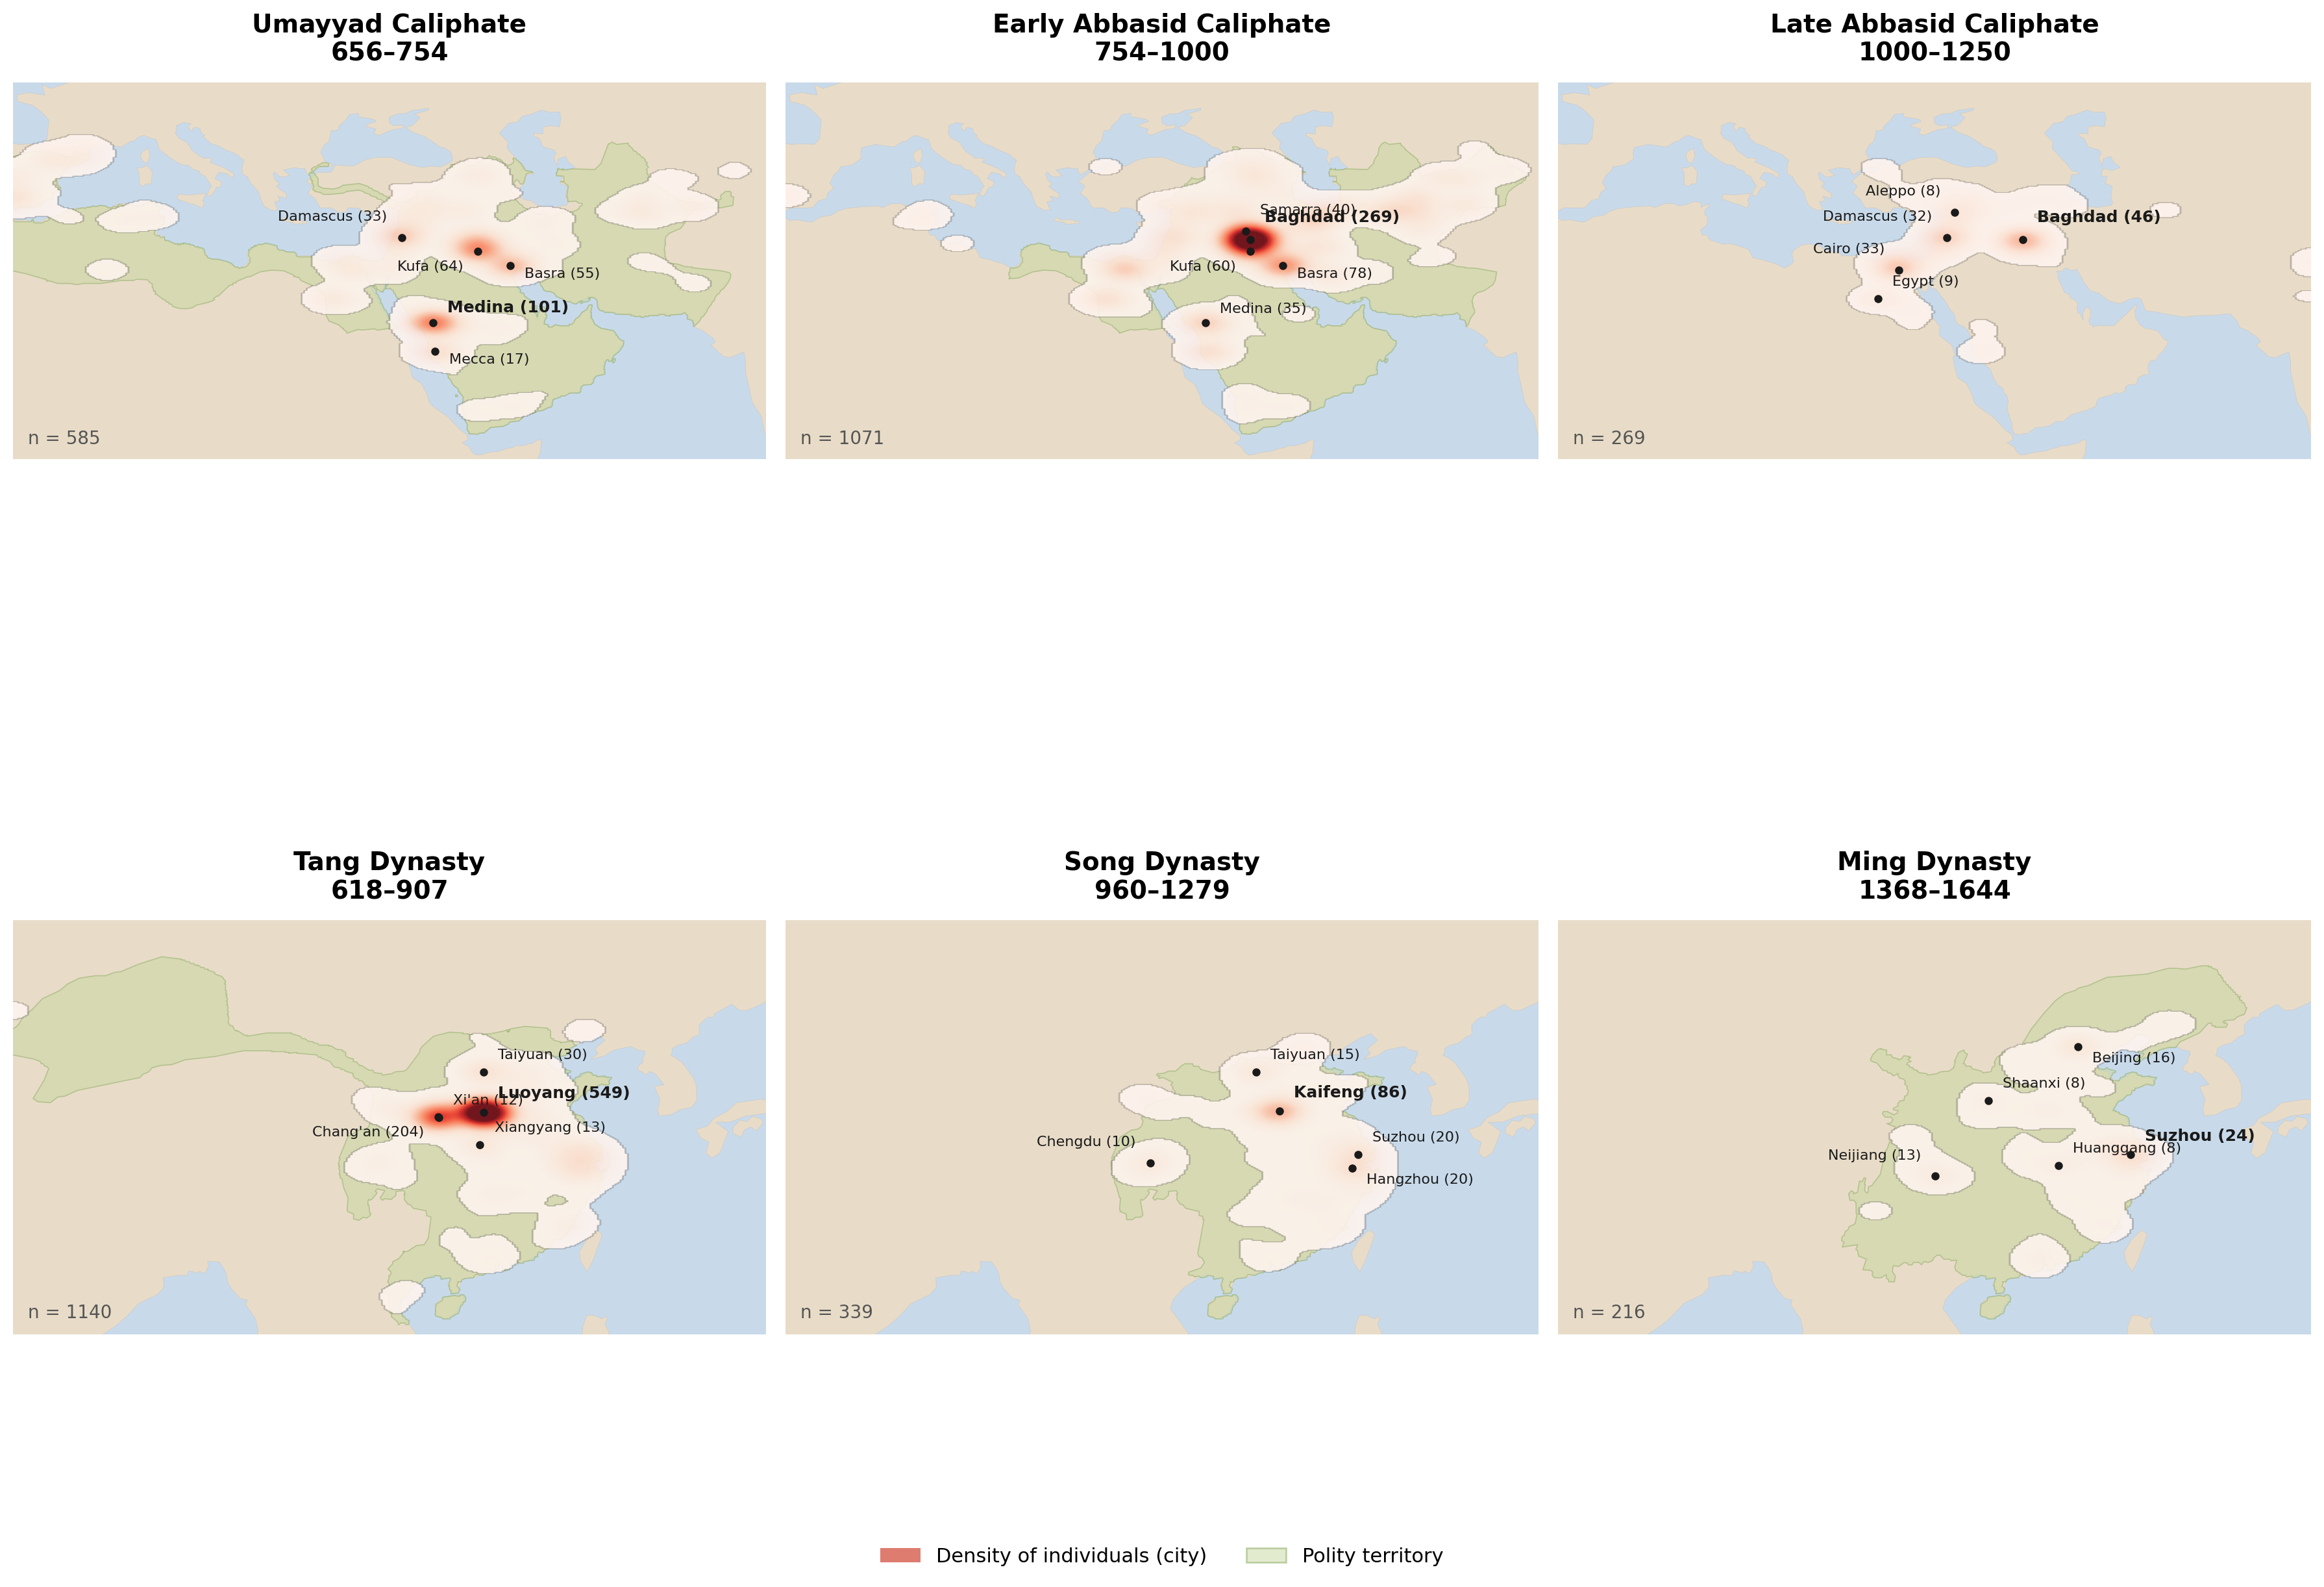

In [7]:
polity_color = '#c8d8a0'
land_color = '#e8dcc8'   # warmer earth-tone background
sea_color = '#c8daea'
grid_res = 300

ME_EXTENT = (-5, 75, 10, 50)
CN_EXTENT = (75, 135, 17, 50)

offsets_me = {
    'Medina': (8, 4), 'Kufa': (-8, -12), 'Basra': (8, -8),
    'Damascus': (-8, 8), 'Baghdad': (8, 8), 'Cairo': (-8, 8),
    'Samarra': (8, 8), 'Karbala': (-8, -12), 'Mecca': (8, -8),
    'Nishapur': (8, 6), 'Isfahan': (-8, -12), 'Bukhara': (8, 6),
    'Rayy': (-8, 8), 'Mosul': (-8, 8), 'Herat': (8, 6),
    'Samarkand': (8, 6), 'Jerusalem': (-8, -12), 'Aleppo': (-8, 8),
    'Fustat': (-8, 8), 'Cordoba': (-8, 8),
}
ha_me = {'Kufa': 'right', 'Damascus': 'right', 'Cairo': 'right',
         'Karbala': 'right', 'Isfahan': 'right', 'Rayy': 'right',
         'Mosul': 'right', 'Jerusalem': 'right', 'Aleppo': 'right',
         'Fustat': 'right', 'Cordoba': 'right'}

offsets_cn = {
    "Chang'an": (-8, -12), 'Luoyang': (8, 6), 'Taiyuan': (8, 6),
    'Kaifeng': (8, 6), 'Hangzhou': (8, -10), 'Suzhou': (8, 6),
    'Beijing': (8, -10), 'Nanjing': (8, -10), 'Neijiang': (-8, 8),
    'Guangzhou': (8, -10), 'Chengdu': (-8, 8), 'Fuzhou': (8, 6),
    'Jinan': (8, 6), 'Shaoxing': (8, 6),
}
ha_cn = {"Chang'an": 'right', 'Neijiang': 'right', 'Chengdu': 'right'}

N_TOP_CITIES = 5


def compute_densities(data_dict, extent, merge_map=None, canonical_coords=None):
    lon_min, lon_max, lat_min, lat_max = extent
    densities = []
    for pkey in data_dict:
        pts = data_dict[pkey]
        merged = []
        for lat, lon, city in pts:
            if merge_map:
                city = merge_map.get(city, city)
                if canonical_coords and city in canonical_coords:
                    lat, lon = canonical_coords[city]
            merged.append((lat, lon))
        lats = np.array([p[0] for p in merged]) if merged else np.array([])
        lons = np.array([p[1] for p in merged]) if merged else np.array([])
        d, _, _ = np.histogram2d(lons, lats, bins=[grid_res, grid_res],
                                 range=[[lon_min, lon_max], [lat_min, lat_max]])
        d = gaussian_filter(d.T, sigma=6)
        densities.append(d)
    vmax = max(d.max() for d in densities)
    return densities, vmax


def draw_row(axes, data_dict, city_counts, period_labels, geos, extent,
             densities, vmax, offsets, ha_map):
    lon_min, lon_max, lat_min, lat_max = extent
    period_keys = list(data_dict.keys())

    for idx, (ax, pkey, plabel, geo, density) in enumerate(
            zip(axes, period_keys, period_labels, geos, densities)):
        ax.set_facecolor(sea_color)
        world.plot(ax=ax, color=land_color, edgecolor='#cccccc', linewidth=0.3)

        if geo is not None:
            gpd.GeoSeries([geo]).plot(ax=ax, color=polity_color,
                                      edgecolor='#8aaa60', linewidth=0.6, alpha=0.5)

        # Stronger red overlay: higher alpha, use 'hot_r' colormap for more contrast
        density_masked = np.ma.masked_where(density < 0.005, density)
        ax.imshow(density_masked, extent=[lon_min, lon_max, lat_min, lat_max],
                  origin='lower', aspect='auto', cmap='Reds', alpha=0.9,
                  vmin=0, vmax=vmax * 0.6, zorder=4, interpolation='bilinear')

        counter = city_counts[pkey]
        top5 = counter.most_common(N_TOP_CITIES)
        for rank, ((clat, clon, cname), cnt) in enumerate(top5):
            dx, dy = offsets.get(cname, (8, 6))
            ha = ha_map.get(cname, 'left')
            fw = 'bold' if rank == 0 else 'normal'
            fs = 9 if rank == 0 else 8
            ax.plot(clon, clat, 'o', color='#1a1a1a', markersize=3.5, zorder=11)
            ax.annotate(f'{cname} ({cnt})', (clon, clat),
                        fontsize=fs, fontweight=fw, color='#1a1a1a',
                        ha=ha, va='bottom',
                        xytext=(dx, dy), textcoords='offset points', zorder=12)

        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.set_aspect('equal')
        ax.set_title(plabel, fontsize=14, fontweight='bold', color='black',
                     loc='center', pad=12)
        n = len(data_dict[pkey])
        ax.text(0.02, 0.03, f'n = {n}', transform=ax.transAxes,
                fontsize=10, color='#555555', va='bottom')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)


dens_me, vmax_me = compute_densities(data_me, ME_EXTENT)
dens_cn, vmax_cn = compute_densities(data_cn, CN_EXTENT, merge_map, canonical_coords)

fig, axes = plt.subplots(2, 3, figsize=(18, 13), dpi=200)

draw_row(axes[0], data_me, city_counts_me, period_labels_me, geos_me,
         ME_EXTENT, dens_me, vmax_me, offsets_me, ha_me)
draw_row(axes[1], data_cn, city_counts_cn, period_labels_cn, geos_cn,
         CN_EXTENT, dens_cn, vmax_cn, offsets_cn, ha_cn)

legend_elements = [
    mpatches.Patch(facecolor='#d45040', alpha=0.75, label='Density of individuals (city)'),
    mpatches.Patch(facecolor=polity_color, edgecolor='#8aaa60',
                   alpha=0.5, label='Polity territory'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.subplots_adjust(bottom=0.04, hspace=0.15)
plt.show()